In [1]:

import pandas as pd
import numpy as np

In [2]:

# Load the dataset (../ moves out of 'notebooks' and looks into 'data/raw/')
df = pd.read_csv('../data/raw/training.1600000.processed.noemoticon.csv',
                encoding='latin-1',
                names=['sentiment', 'id', 'date', 'query', 'user', 'text'])


In [3]:
#see the first 5 rows

df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
#check the shapes (rows, columns)

print('Shape:',df.shape)

Shape: (1600000, 6)


In [5]:
#check the data types

print(df.dtypes)

sentiment    int64
id           int64
date           str
query          str
user           str
text           str
dtype: object


In [6]:
# Check for missing values
print(df.isnull().sum())


sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64


In [7]:
# Check sentiment value counts
print(df['sentiment'].value_counts())
# In Sentiment140: 0 = Negative, 4 = Positive

sentiment
0    800000
4    800000
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3540\3931048674.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette=['#EF4444', '#22C55E'])


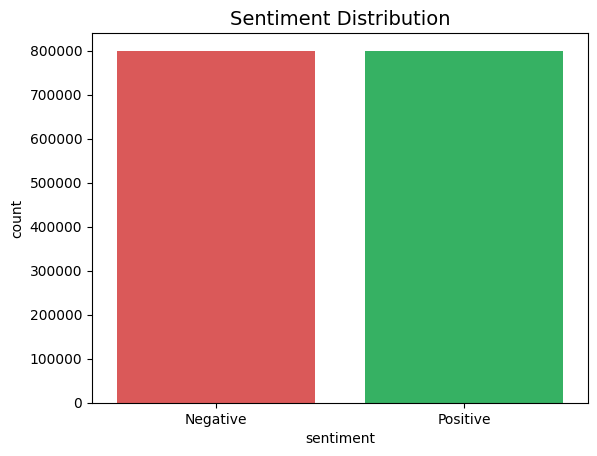

In [8]:
##EDA

import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 — Sentiment Distribution
sns.countplot(x='sentiment', data=df, palette=['#EF4444', '#22C55E'])
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Sentiment Distribution', fontsize=14)
plt.savefig('reports/01_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


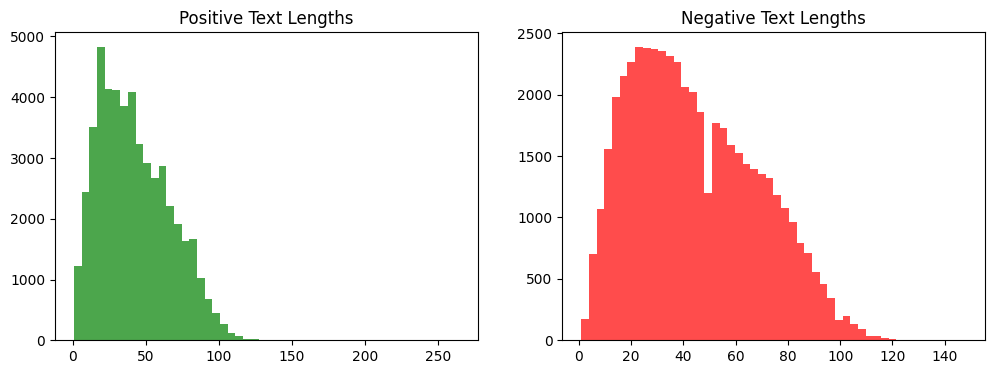

In [9]:
# Load the correct clean data first so 'clean_text' exists
df = pd.read_csv('../data/processed/clean_data.csv')

# Chart 2 — Text Length Distribution
df['text_length'] = df['clean_text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df['sentiment']==1]['text_length'], bins=50, color='green', alpha=0.7)
axes[0].set_title('Positive Text Lengths')

axes[1].hist(df[df['sentiment']==0]['text_length'], bins=50, color='red', alpha=0.7)
axes[1].set_title('Negative Text Lengths')

plt.savefig('reports/02_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()


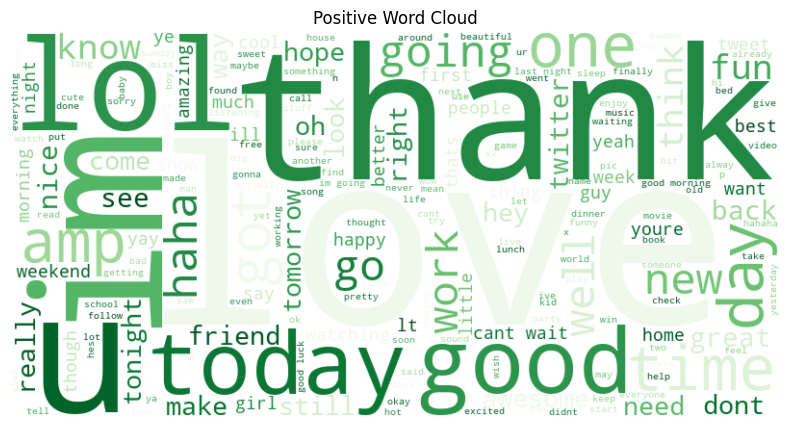

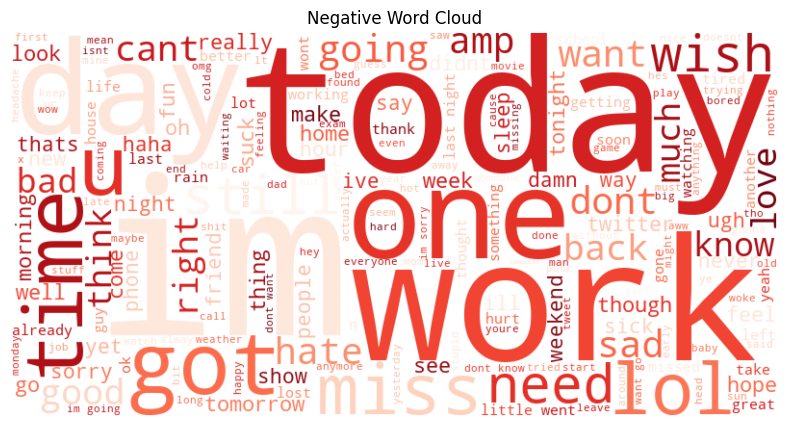

In [10]:
from wordcloud import WordCloud

# Chart 3 — Most Common Words (Word Cloud)
for label, name, color in [(1, 'Positive', 'Greens'), (0, 'Negative', 'Reds')]:
    text = ' '.join(df[df['sentiment']==label]['clean_text'])
    
    wc = WordCloud(width=800, height=400, colormap=color, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{name} Word Cloud')
    plt.savefig(f'reports/03_wordcloud_{name.lower()}.png', dpi=150)
    plt.show()


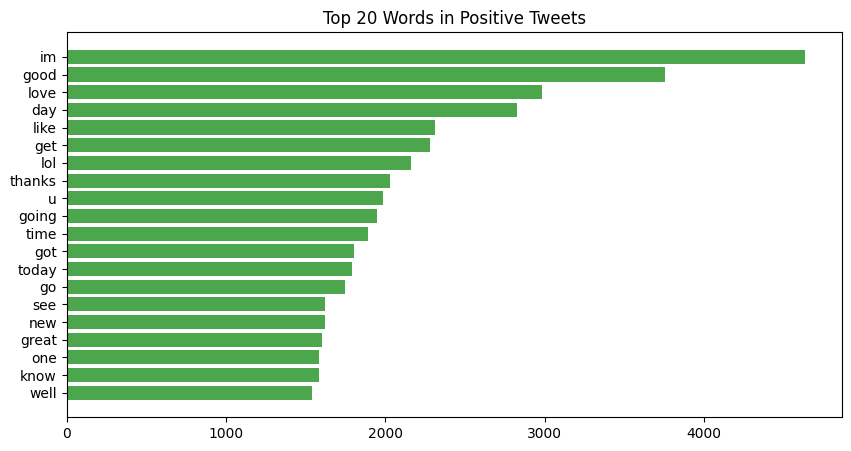

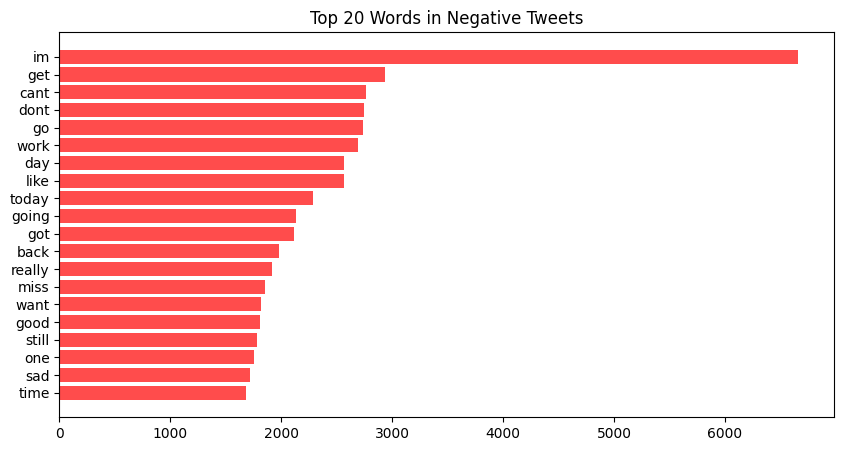

In [11]:
from collections import Counter
import matplotlib.pyplot as plt

# Load the correct clean data first so 'clean_text' exists
df = pd.read_csv('../data/processed/clean_data.csv')

# Chart 4 — Top 20 Most Frequent Words
for label, name, color in [(1, 'Positive', 'green'), (0, 'Negative', 'red')]:
    all_words = ' '.join(df[df['sentiment']==label]['clean_text']).split()
    top = Counter(all_words).most_common(20)
    words, counts = zip(*top)
    
    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], counts[::-1], color=color, alpha=0.7)
    plt.title(f'Top 20 Words in {name} Tweets')
    plt.savefig(f'reports/04_top_words_{name.lower()}.png', dpi=150)
    plt.show()
